# Trích xuất đặc trưng văn bản (Feature Extraction)
### Dữ liệu: `merged_cleaned_data.json` — 12,018 bản ghi y tế tiếng Việt

**7 phương pháp được thực hiện:**
1. One-hot Encoding
2. Count Vectorizing
3. N-grams
4. Co-occurrence Matrix
5. Hash Vectorizing
6. TF-IDF
7. Word Embedding (Word2Vec)

In [1]:
# ── Cài thư viện cần thiết ──────────────────────────────────────
# Chạy 1 lần nếu chưa có
# !pip install scikit-learn gensim matplotlib seaborn pandas numpy scipy

In [2]:
import json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# ── Load dữ liệu ────────────────────────────────────────────────
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                         'merged_cleaned_data.json')

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Lấy danh sách văn bản
corpus = [d['cleaned_text'] for d in raw_data]
print(f'Tổng bản ghi  : {len(corpus):,}')
print(f'Ví dụ mẫu     : {corpus[0][:120]}...')

# Subset nhỏ cho các phương pháp cost-cao (One-hot, Co-occurrence)
SAMPLE_SIZE   = 500   # dùng 500 doc để minh hoạ
VOCAB_LIMIT   = 200   # giới hạn vocab cho One-hot & Co-occurrence
corpus_sample = corpus[:SAMPLE_SIZE]

Tổng bản ghi  : 12,018
Ví dụ mẫu     : httpswwwvinmeccomviebenhutebaokhonglo4453 20260201 t201259462118 nguyên nhân gây bệnh u tế bào khổng lồ hiện nay tranh c...


---
## 1. One-hot Encoding
Mỗi từ trong từ điển được mã hoá thành vector nhị phân: `1` nếu từ xuất hiện trong tài liệu, `0` nếu không có.

In [3]:
from sklearn.preprocessing import MultiLabelBinarizer

# Xây dựng vocab từ top-N từ phổ biến nhất
all_words = []
for doc in corpus_sample:
    all_words.extend(doc.split())
vocab_counter = Counter(all_words)
top_vocab = [w for w, _ in vocab_counter.most_common(VOCAB_LIMIT)]
vocab_set = set(top_vocab)

# Mã hoá: mỗi doc → tập từ (chỉ giữ từ trong vocab)
doc_word_sets = [set(doc.split()) & vocab_set for doc in corpus_sample]

mlb = MultiLabelBinarizer(classes=top_vocab)
onehot_matrix = mlb.fit_transform(doc_word_sets)

print(f'One-hot matrix shape : {onehot_matrix.shape}')
print(f'  → {onehot_matrix.shape[0]} tài liệu  ×  {onehot_matrix.shape[1]} từ trong vocab')
print(f'Sparsity             : {(onehot_matrix == 0).sum() / onehot_matrix.size * 100:.1f}%')
print(f'\nVí dụ vector của doc[0] (20 chiều đầu):')
print(onehot_matrix[0, :20])
print('Từ tương ứng:', top_vocab[:20])

One-hot matrix shape : (500, 200)
  → 500 tài liệu  ×  200 từ trong vocab
Sparsity             : 34.3%

Ví dụ vector của doc[0] (20 chiều đầu):
[1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1]
Từ tương ứng: ['bệnh', 'thể', 'có', 'thuốc', 'người', 'điều', 'cơ', 'trị', 'nhân', 'thường', 'dụng', 'máu', 'sinh', 'hiện', 'gây', 'động', 'sử', 'viêm', 'nhiễm', 'tăng']


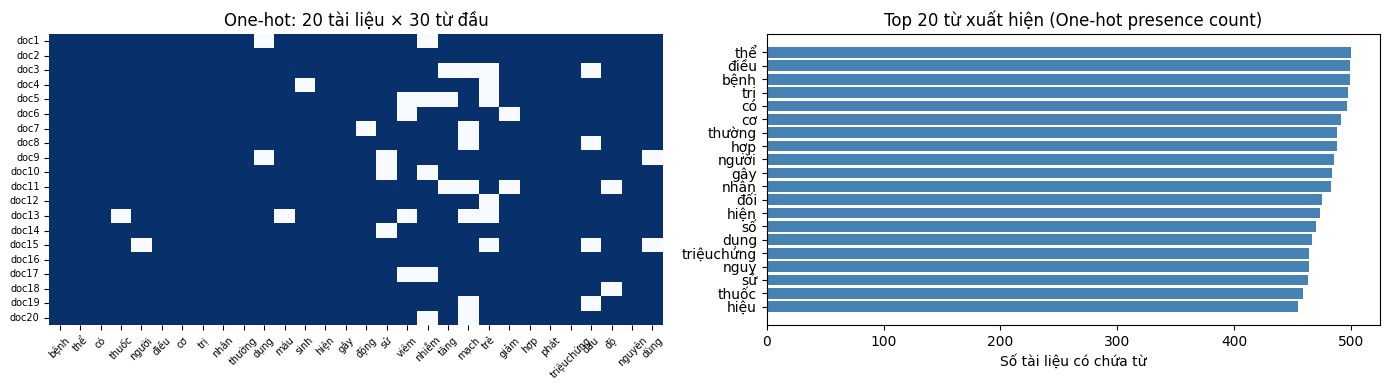

✓ Saved: onehot_result.png


In [4]:
# ── Visualize One-hot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap 20 doc × 30 từ đầu
sns.heatmap(onehot_matrix[:20, :30], ax=axes[0],
            cmap='Blues', cbar=False,
            xticklabels=top_vocab[:30], yticklabels=[f'doc{i+1}' for i in range(20)])
axes[0].set_title('One-hot: 20 tài liệu × 30 từ đầu')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Top 20 từ xuất hiện nhiều nhất
word_presence = onehot_matrix.sum(axis=0)
top_idx = np.argsort(word_presence)[::-1][:20]
axes[1].barh([top_vocab[i] for i in top_idx][::-1],
             word_presence[top_idx][::-1], color='steelblue')
axes[1].set_title('Top 20 từ xuất hiện (One-hot presence count)')
axes[1].set_xlabel('Số tài liệu có chứa từ')

plt.tight_layout()
plt.savefig('onehot_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved: onehot_result.png')

---
## 2. Count Vectorizing
Đếm số lần xuất hiện của mỗi từ trong tài liệu (Bag-of-Words). Không chỉ nhị phân như One-hot mà giữ tần suất thực tế.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000, min_df=2)
count_matrix = cv.fit_transform(corpus)   # dùng toàn bộ corpus
cv_vocab = cv.get_feature_names_out()

print(f'Count matrix shape : {count_matrix.shape}')
print(f'  → {count_matrix.shape[0]} tài liệu  ×  {count_matrix.shape[1]} từ')
print(f'Sparsity           : {(1 - count_matrix.nnz / (count_matrix.shape[0]*count_matrix.shape[1]))*100:.1f}%')
print(f'\nTop 15 từ theo tổng tần số:')
word_freq = np.array(count_matrix.sum(axis=0)).flatten()
top15_idx = np.argsort(word_freq)[::-1][:15]
for i in top15_idx:
    print(f'  {cv_vocab[i]:<20} {int(word_freq[i]):>8,}')

Count matrix shape : (12018, 5000)
  → 12018 tài liệu  ×  5000 từ
Sparsity           : 93.6%

Top 15 từ theo tổng tần số:
  thể                   226,017
  thuốc                 195,866
  bệnh                  172,219
  có                    165,269
  dụng                  141,852
  người                 114,628
  điều                  104,605
  trị                    94,710
  dùng                   90,862
  cơ                     89,606
  sử                     85,314
  thường                 77,675
  nhân                   70,891
  gây                    67,404
  da                     67,228


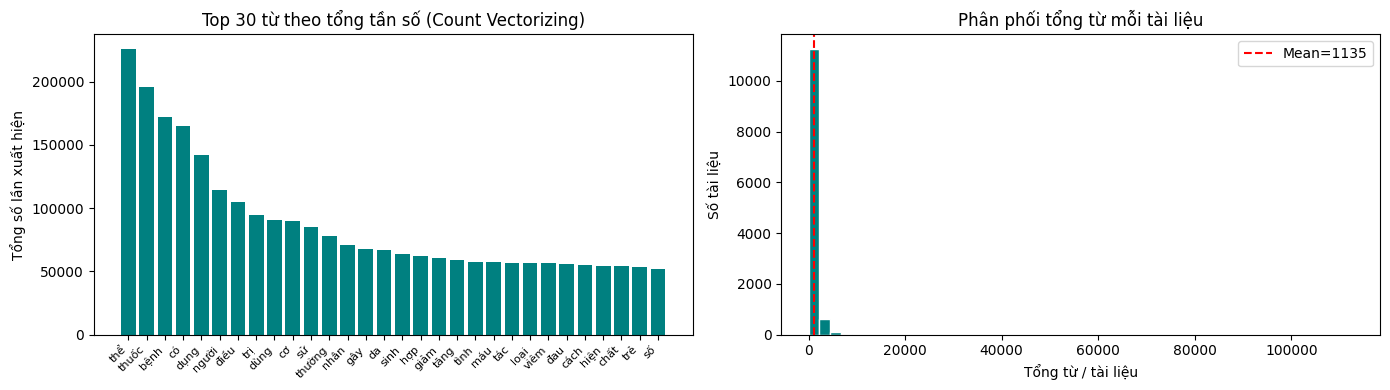

✓ Saved: count_vectorizer_result.png


In [6]:
# ── Visualize Count Vectorizing ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart top 30 từ
top30_idx = np.argsort(word_freq)[::-1][:30]
axes[0].bar(range(30), word_freq[top30_idx], color='teal')
axes[0].set_xticks(range(30))
axes[0].set_xticklabels([cv_vocab[i] for i in top30_idx], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Top 30 từ theo tổng tần số (Count Vectorizing)')
axes[0].set_ylabel('Tổng số lần xuất hiện')

# Phân phối số từ / tài liệu
doc_lengths = np.array(count_matrix.sum(axis=1)).flatten()
axes[1].hist(doc_lengths, bins=50, color='teal', edgecolor='white')
axes[1].set_title('Phân phối tổng từ mỗi tài liệu')
axes[1].set_xlabel('Tổng từ / tài liệu')
axes[1].set_ylabel('Số tài liệu')
axes[1].axvline(doc_lengths.mean(), color='red', linestyle='--', label=f'Mean={doc_lengths.mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('count_vectorizer_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved: count_vectorizer_result.png')

---
## 3. N-grams
Mở rộng Bag-of-Words sang chuỗi n từ liên tiếp (bigram = 2 từ, trigram = 3 từ) để nắm bắt ngữ cảnh cục bộ.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

results = {}
for n, label in [(1,'Unigram'), (2,'Bigram'), (3,'Trigram')]:
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000, min_df=2)
    mat = vec.fit_transform(corpus)
    vocab_n = vec.get_feature_names_out()
    freq_n  = np.array(mat.sum(axis=0)).flatten()
    top10   = np.argsort(freq_n)[::-1][:10]
    results[label] = {'vocab': vocab_n, 'freq': freq_n, 'top10': top10, 'shape': mat.shape}
    print(f'{label}: shape={mat.shape}, top-3: {[vocab_n[i] for i in top10[:3]]}')

print('\nTop 10 bigrams:')
for i in results['Bigram']['top10']:
    print(f"  {results['Bigram']['vocab'][i]:<30} {int(results['Bigram']['freq'][i]):>8,}")

Unigram: shape=(12018, 5000), top-3: ['thể', 'thuốc', 'bệnh']
Bigram: shape=(12018, 5000), top-3: ['có thể', 'sử dụng', 'điều trị']
Trigram: shape=(12018, 5000), top-3: ['sử dụng thuốc', 'có thể gây', 'tác dụng phụ']

Top 10 bigrams:
  có thể                          158,216
  sử dụng                          78,095
  điều trị                         75,150
  tình trạng                       39,255
  tác dụng                         37,833
  một số                           34,302
  người bệnh                       32,297
  bệnh nhân                        32,019
  dụng thuốc                       28,070
  nguy cơ                          27,688


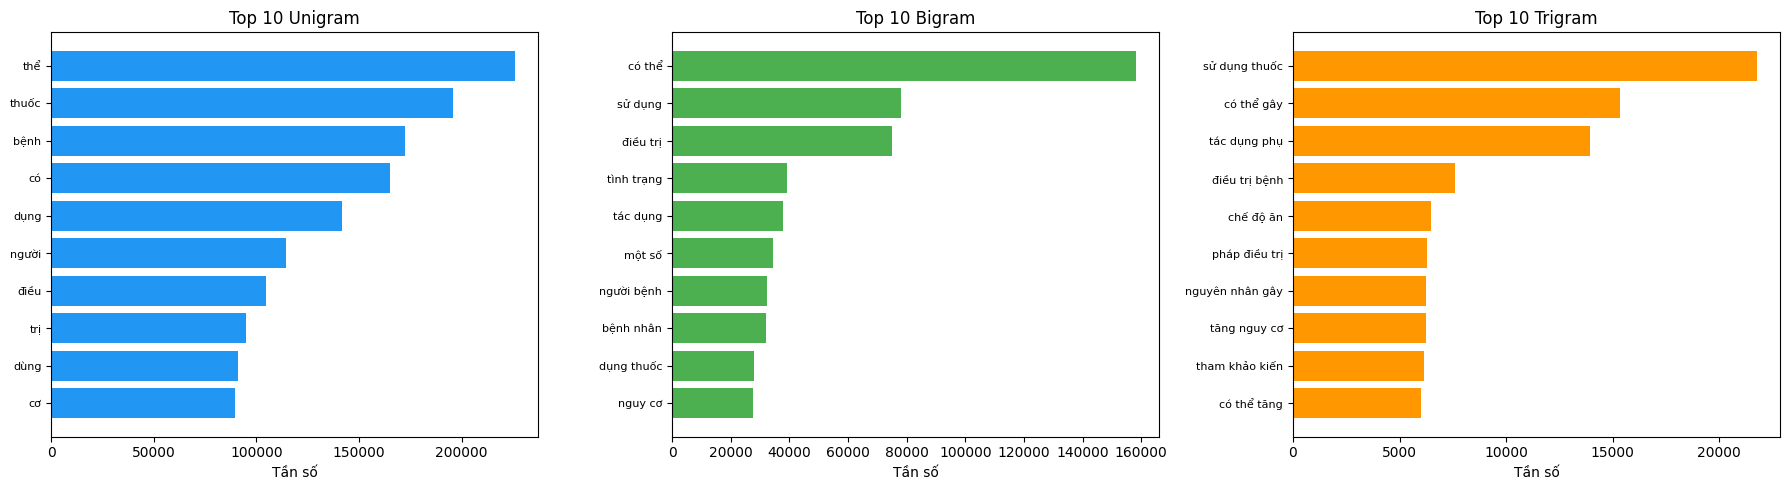

✓ Saved: ngrams_result.png


In [8]:
# ── Visualize N-grams ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, (label, color) in zip(axes, zip(results.keys(), colors)):
    top20 = results[label]['top10'][::-1]  # reverse for horizontal bar
    words = [results[label]['vocab'][i] for i in top20]
    freqs = [results[label]['freq'][i]  for i in top20]
    ax.barh(words, freqs, color=color)
    ax.set_title(f'Top 10 {label}')
    ax.set_xlabel('Tần số')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('ngrams_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved: ngrams_result.png')

---
## 4. Co-occurrence Matrix
Ma trận đồng xuất hiện: đếm số lần từ A và từ B cùng xuất hiện trong một cửa sổ ngữ cảnh (window). Cho biết mối quan hệ giữa các từ.

In [9]:
from scipy.sparse import lil_matrix

COOC_VOCAB_SIZE = 100   # chỉ dùng top-100 từ
WINDOW_SIZE     = 4

# Xây dựng vocab top-N
all_w = []
for doc in corpus_sample:
    all_w.extend(doc.split())
cooc_vocab = [w for w, _ in Counter(all_w).most_common(COOC_VOCAB_SIZE)]
w2i = {w: i for i, w in enumerate(cooc_vocab)}

# Xây dựng co-occurrence
cooc = lil_matrix((COOC_VOCAB_SIZE, COOC_VOCAB_SIZE), dtype=np.float32)

for doc in corpus_sample:
    tokens = doc.split()
    for idx, word in enumerate(tokens):
        if word not in w2i:
            continue
        wi = w2i[word]
        start = max(0, idx - WINDOW_SIZE)
        end   = min(len(tokens), idx + WINDOW_SIZE + 1)
        for jdx in range(start, end):
            if jdx != idx and tokens[jdx] in w2i:
                wj = w2i[tokens[jdx]]
                cooc[wi, wj] += 1

cooc_dense = cooc.toarray()
print(f'Co-occurrence matrix shape : {cooc_dense.shape}')
print(f'Non-zero entries           : {(cooc_dense > 0).sum():,}')

# Top cặp từ đồng xuất hiện nhiều nhất
flat_idx = np.argsort(cooc_dense.flatten())[::-1][:10]
print('\nTop 10 cặp từ đồng xuất hiện:')
for fi in flat_idx:
    r, c = divmod(fi, COOC_VOCAB_SIZE)
    if r != c:
        print(f'  ({cooc_vocab[r]}, {cooc_vocab[c]}) → {int(cooc_dense[r,c]):,}')

Co-occurrence matrix shape : (100, 100)
Non-zero entries           : 9,994

Top 10 cặp từ đồng xuất hiện:
  (thể, có) → 18,981
  (có, thể) → 18,981
  (điều, trị) → 12,011
  (trị, điều) → 12,011
  (nhân, bệnh) → 8,999
  (bệnh, nhân) → 8,999
  (người, bệnh) → 7,668
  (bệnh, người) → 7,668
  (sử, dụng) → 7,602
  (dụng, sử) → 7,602


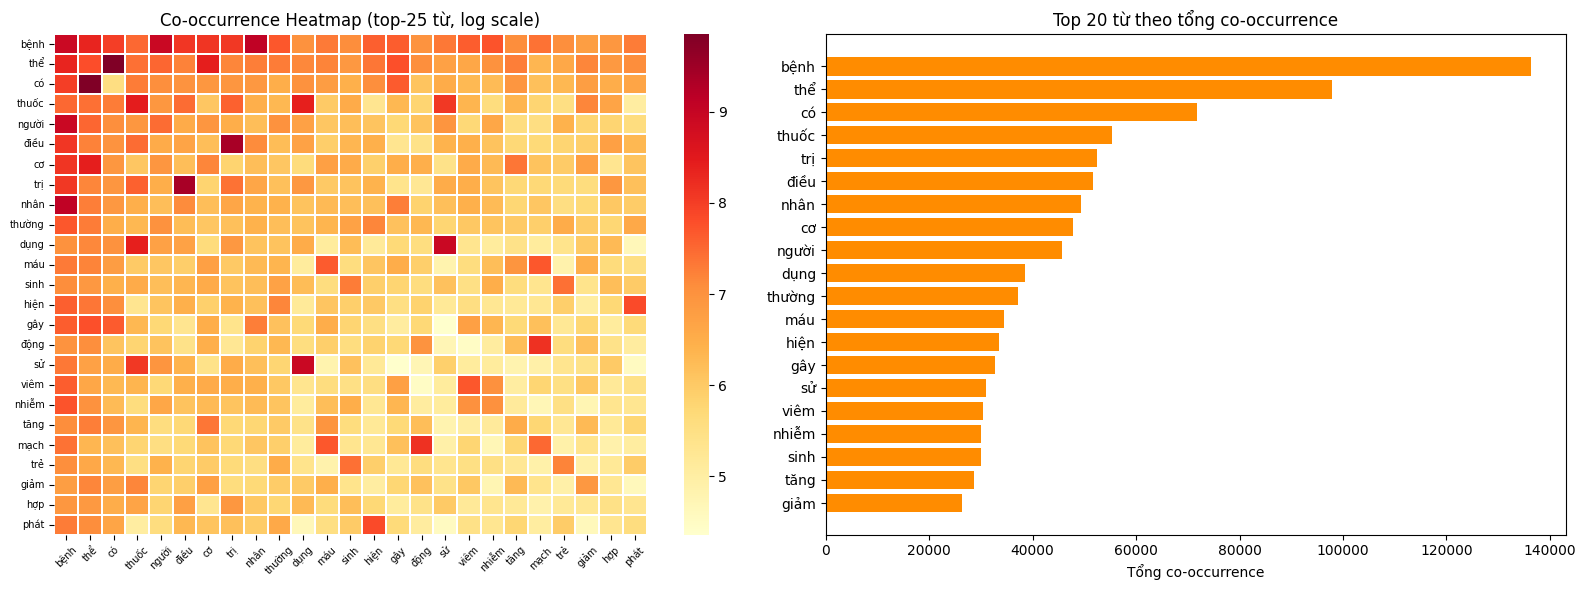

✓ Saved: cooccurrence_result.png


In [10]:
# ── Visualize Co-occurrence ──────────────────────────────────────
SHOW = 25  # hiển thị 25×25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(np.log1p(cooc_dense[:SHOW, :SHOW]), ax=axes[0],
            xticklabels=cooc_vocab[:SHOW], yticklabels=cooc_vocab[:SHOW],
            cmap='YlOrRd', linewidths=0.3)
axes[0].set_title(f'Co-occurrence Heatmap (top-{SHOW} từ, log scale)')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

# Bar chart tổng co-occurrence mỗi từ
row_sums = cooc_dense.sum(axis=1)
top_cooc = np.argsort(row_sums)[::-1][:20]
axes[1].barh([cooc_vocab[i] for i in top_cooc][::-1],
             row_sums[top_cooc][::-1], color='darkorange')
axes[1].set_title('Top 20 từ theo tổng co-occurrence')
axes[1].set_xlabel('Tổng co-occurrence')

plt.tight_layout()
plt.savefig('cooccurrence_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved: cooccurrence_result.png')

---
## 5. Hash Vectorizing
Dùng hàm băm (hash function) để ánh xạ từ vào vector cố định mà không cần lưu từ điển. Phù hợp với dữ liệu lớn và streaming.

In [11]:
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=2**16, norm='l2', alternate_sign=False)
hash_matrix = hv.transform(corpus)

print(f'Hash matrix shape  : {hash_matrix.shape}')
print(f'  → {hash_matrix.shape[0]} tài liệu  ×  {hash_matrix.shape[1]:,} buckets')
print(f'Non-zero per doc   : {hash_matrix.nnz / hash_matrix.shape[0]:.1f} trung bình')
print(f'Sparsity           : {(1 - hash_matrix.nnz/(hash_matrix.shape[0]*hash_matrix.shape[1]))*100:.2f}%')

# Phân phối giá trị non-zero của doc đầu tiên
doc0 = hash_matrix[0].toarray().flatten()
nonzero_vals = doc0[doc0 > 0]
print(f'\nDoc[0] non-zero entries: {len(nonzero_vals)}')
print(f'Min / Max value        : {nonzero_vals.min():.4f} / {nonzero_vals.max():.4f}')

Hash matrix shape  : (12018, 65536)
  → 12018 tài liệu  ×  65,536 buckets
Non-zero per doc   : 341.9 trung bình
Sparsity           : 99.48%

Doc[0] non-zero entries: 418
Min / Max value        : 0.0030 / 0.4430


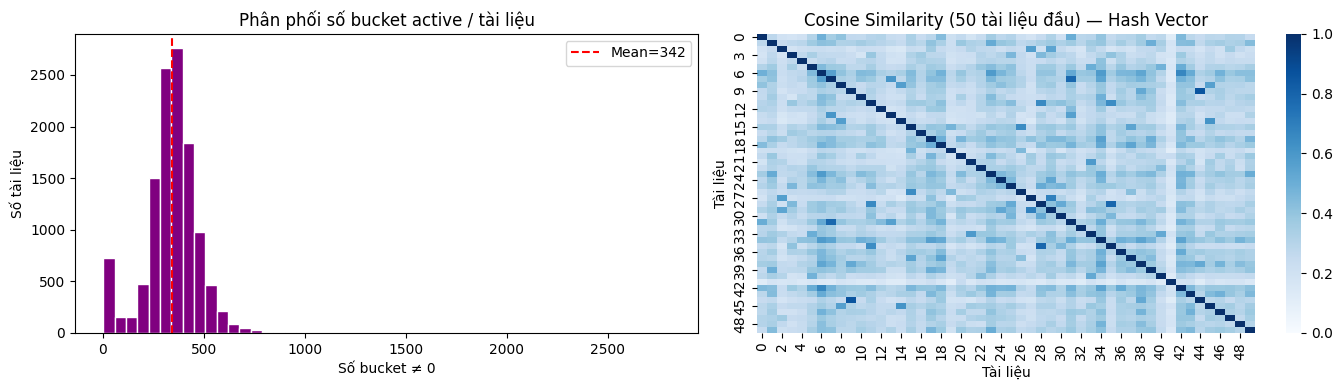

✓ Saved: hash_vectorizer_result.png


In [12]:
# ── Visualize Hash Vectorizing ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Phân phối số non-zero / tài liệu
nnz_per_doc = np.diff(hash_matrix.indptr)
axes[0].hist(nnz_per_doc, bins=50, color='purple', edgecolor='white')
axes[0].set_title('Phân phối số bucket active / tài liệu')
axes[0].set_xlabel('Số bucket ≠ 0')
axes[0].set_ylabel('Số tài liệu')
axes[0].axvline(nnz_per_doc.mean(), color='red', linestyle='--',
                label=f'Mean={nnz_per_doc.mean():.0f}')
axes[0].legend()

# Cosine similarity giữa 50 tài liệu đầu (dùng hash vector)
from sklearn.metrics.pairwise import cosine_similarity
sim50 = cosine_similarity(hash_matrix[:50])
sns.heatmap(sim50, ax=axes[1], cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Cosine Similarity (50 tài liệu đầu) — Hash Vector')
axes[1].set_xlabel('Tài liệu')
axes[1].set_ylabel('Tài liệu')

plt.tight_layout()
plt.savefig('hash_vectorizer_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved: hash_vectorizer_result.png')

---
## 6. TF-IDF
Term Frequency–Inverse Document Frequency: kết hợp tần số từ trong tài liệu (TF) với mức độ hiếm của từ trên toàn corpus (IDF). Từ phổ biến khắp nơi được giảm trọng số.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, min_df=2, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(corpus)
tfidf_vocab  = tfidf.get_feature_names_out()
idf_vals     = tfidf.idf_

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'Sparsity            : {(1 - tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1]))*100:.1f}%')

# Từ có IDF cao nhất (hiếm, đặc trưng)
top_idf_idx = np.argsort(idf_vals)[::-1][:15]
print('\nTop 15 từ có IDF cao nhất (đặc trưng nhất):')
for i in top_idf_idx:
    print(f'  {tfidf_vocab[i]:<25} IDF={idf_vals[i]:.4f}')

# Từ có IDF thấp nhất (phổ biến)
bot_idf_idx = np.argsort(idf_vals)[:15]
print('\nTop 15 từ có IDF thấp nhất (phổ biến nhất):')
for i in bot_idf_idx:
    print(f'  {tfidf_vocab[i]:<25} IDF={idf_vals[i]:.4f}')

TF-IDF matrix shape : (12018, 10000)
Sparsity            : 96.8%

Top 15 từ có IDF cao nhất (đặc trưng nhất):
  bonnet                    IDF=9.2956
  hydroxocobalamin          IDF=9.2956
  truxima                   IDF=9.2956
  hydrite                   IDF=9.2956
  bermoric                  IDF=9.2956
  amriamid                  IDF=9.2956
  anaplasma                 IDF=9.2956
  pyridostigmin             IDF=9.2956
  pyzacar                   IDF=9.2956
  volkmann                  IDF=9.2956
  androidlink               IDF=9.2956
  chill                     IDF=9.2956
  chlorella                 IDF=9.2956
  il17a                     IDF=9.2956
  issue                     IDF=9.2956

Top 15 từ có IDF thấp nhất (phổ biến nhất):
  thể                       IDF=1.0566
  có                        IDF=1.0593
  điều                      IDF=1.1102
  thường                    IDF=1.1176
  người                     IDF=1.1305
  cơ                        IDF=1.1376
  hợp                     

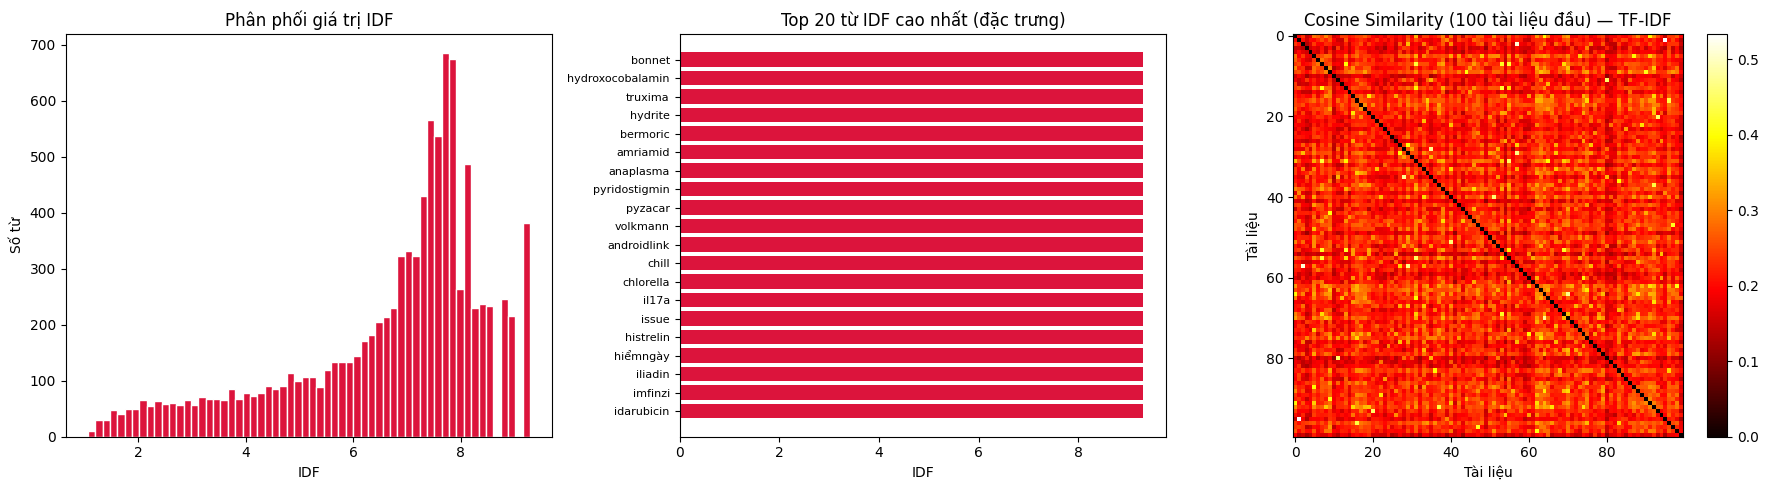

✓ Saved: tfidf_result.png


In [14]:
# ── Visualize TF-IDF ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Phân phối IDF
axes[0].hist(idf_vals, bins=60, color='crimson', edgecolor='white')
axes[0].set_title('Phân phối giá trị IDF')
axes[0].set_xlabel('IDF')
axes[0].set_ylabel('Số từ')

# Top 20 từ IDF cao nhất
top20_idf = np.argsort(idf_vals)[::-1][:20]
axes[1].barh([tfidf_vocab[i] for i in top20_idf][::-1],
             [idf_vals[i]    for i in top20_idf][::-1], color='crimson')
axes[1].set_title('Top 20 từ IDF cao nhất (đặc trưng)')
axes[1].set_xlabel('IDF')
axes[1].tick_params(axis='y', labelsize=8)

# Cosine similarity TF-IDF cho 100 tài liệu đầu
from sklearn.metrics.pairwise import cosine_similarity
sim100 = cosine_similarity(tfidf_matrix[:100])
np.fill_diagonal(sim100, 0)
im = axes[2].imshow(sim100, cmap='hot', aspect='auto')
plt.colorbar(im, ax=axes[2])
axes[2].set_title('Cosine Similarity (100 tài liệu đầu) — TF-IDF')
axes[2].set_xlabel('Tài liệu')
axes[2].set_ylabel('Tài liệu')

plt.tight_layout()
plt.savefig('tfidf_result.png', bbox_inches='tight')
plt.show()
print('✓ Saved: tfidf_result.png')

---
## 7. Word Embedding (Word2Vec)
Học vector dày đặc (dense) cho mỗi từ dựa trên ngữ cảnh xung quanh. Từ có nghĩa tương tự sẽ có vector gần nhau trong không gian embedding.

In [15]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from gensim.models import Word2Vec  

# Tokenize corpus thành danh sách từ
tokenized = [doc.split() for doc in corpus] # sai vì tiếng việt cần tokenizer theo cụm từ

# Train Word2Vec
w2v_model = Word2Vec(
    sentences  = tokenized,
    vector_size= 100,
    window     = 5,
    min_count  = 3,
    workers    = 4,
    sg         = 1,      # Skip-gram
    epochs     = 10,
)

print(f'Vocab size   : {len(w2v_model.wv):,} từ')
print(f'Vector size  : {w2v_model.wv.vector_size}')

# Từ gần nhất với một số từ y tế
QUERY_WORDS = ['bệnh', 'thuốc', 'triệuchứng', 'điềutrị', 'bácsĩ']
for qw in QUERY_WORDS:
    if qw in w2v_model.wv:
        similar = w2v_model.wv.most_similar(qw, topn=5)
        similar_str = ', '.join([f'{w}({s:.3f})' for w,s in similar])
        print(f'  {qw:<20} → {similar_str}')
    else:
        print(f'  "{qw}" không có trong vocab')

Vocab size   : 35,669 từ
Vector size  : 100
  bệnh                 → các(0.757), liễunhư(0.718), thầnkhác(0.715), liễudo(0.713), rangười(0.709)
  thuốc                → nhưisotretinoin(0.676), toa(0.662), nhưthuốc(0.638), dùng(0.635), histamineđường(0.631)
  triệuchứng           → dấu(0.736), gốikhông(0.727), nhữngtriệuchứngnhư(0.709), sốtsốt(0.708), đầunghiêm(0.704)
  "điềutrị" không có trong vocab
  bácsĩ                → bác(0.725), bácsĩbạn(0.684), bácsĩda(0.637), liễunếu(0.626), cácbácsĩ(0.624)


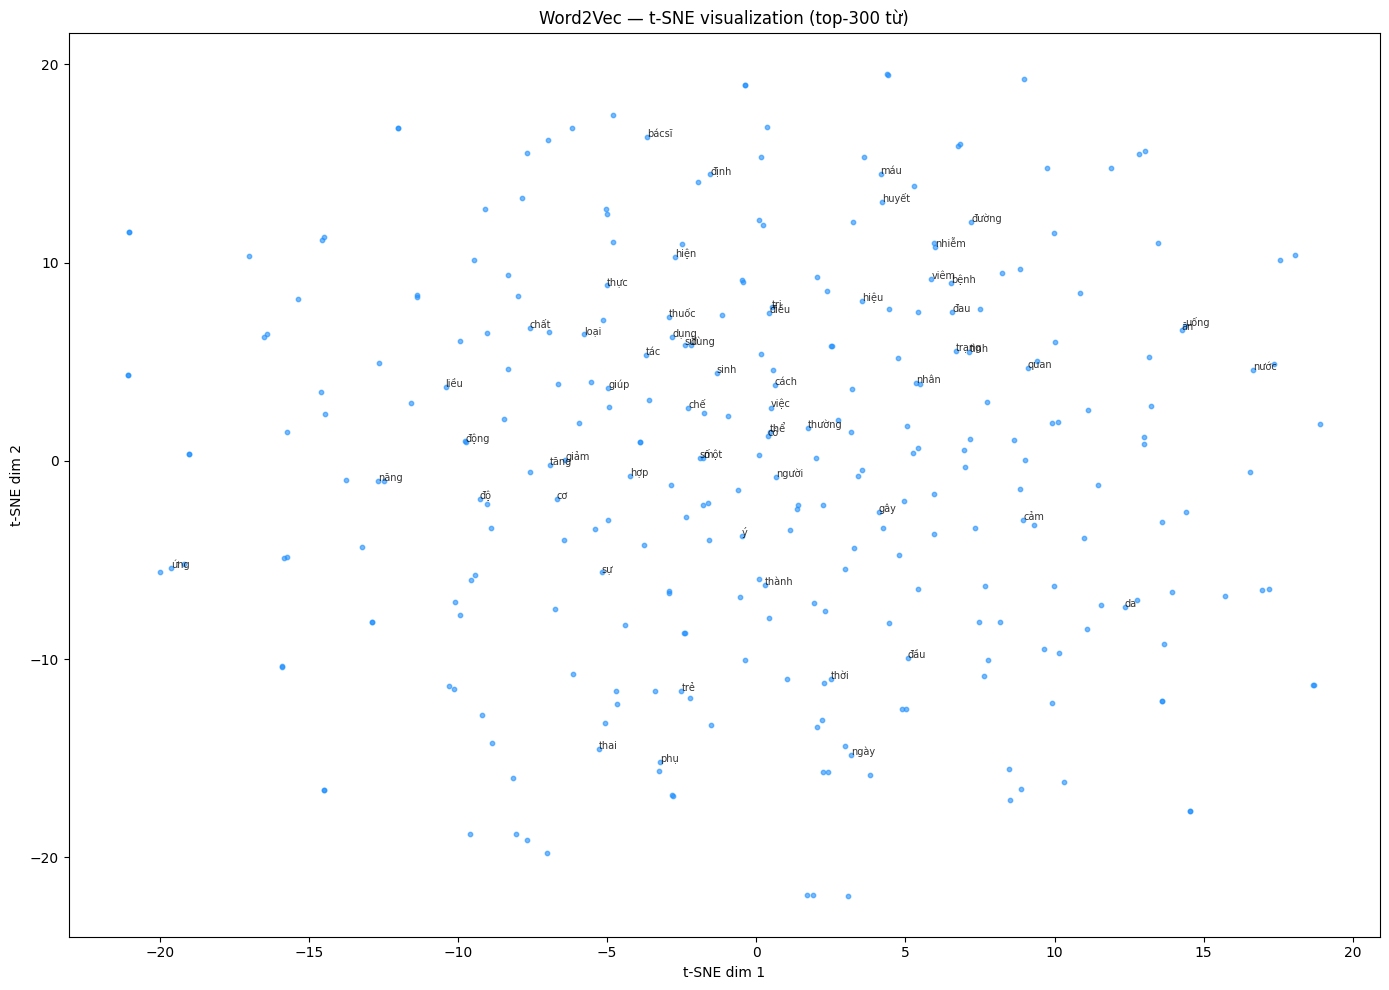

✓ Saved: word2vec_tsne.png


In [17]:
# ── Visualize Word2Vec — t-SNE ────────────────────────────────────
from sklearn.manifold import TSNE

# Lấy top-200 từ phổ biến nhất có trong vocab
wv_vocab = list(w2v_model.wv.key_to_index.keys())
# Lấy 300 từ, bỏ qua URL/số
filtered = [w for w in wv_vocab if not re.match(r'^[0-9a-z]{10,}$', w)][:300]

vectors = np.array([w2v_model.wv[w] for w in filtered])

# t-SNE giảm xuống 2 chiều
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
coords = tsne.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.6, color='dodgerblue')

# Annotate top-60 từ
for i, word in enumerate(filtered[:60]):
    ax.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.8)

ax.set_title('Word2Vec — t-SNE visualization (top-300 từ)')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('word2vec_tsne.png', bbox_inches='tight')
plt.show()
print('✓ Saved: word2vec_tsne.png')


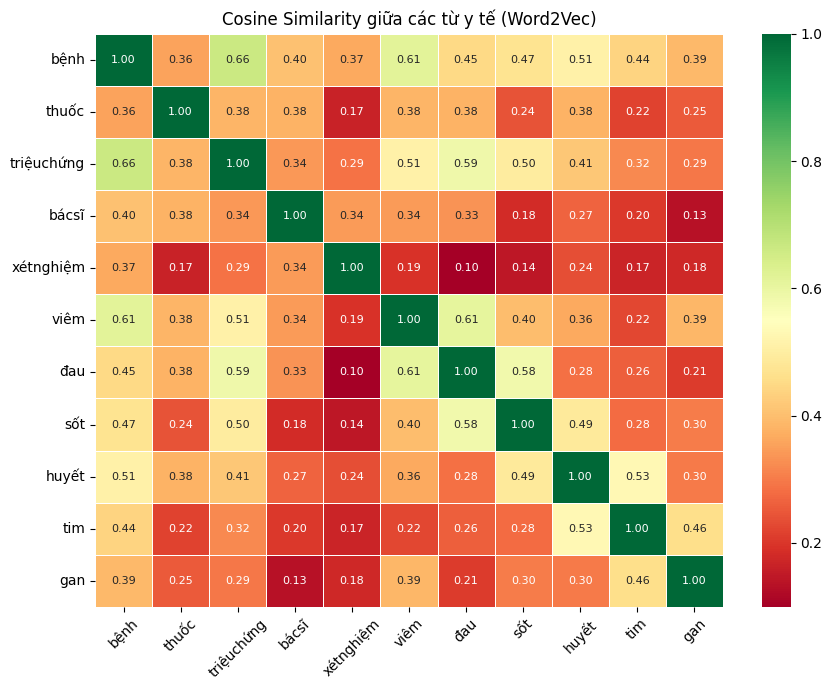

✓ Saved: word2vec_similarity.png


In [18]:
# ── Word similarity heatmap ──────────────────────────────────────
PROBE_WORDS = [w for w in ['bệnh','thuốc','triệuchứng','điềutrị','bácsĩ',
                            'phẫu_thuật','xétnghiệm','chẩnđoán','bệnhnhân',
                            'viêm','đau','sốt','huyết','tim','gan']
               if w in w2v_model.wv]

sim_matrix = np.zeros((len(PROBE_WORDS), len(PROBE_WORDS)))
for i, wi in enumerate(PROBE_WORDS):
    for j, wj in enumerate(PROBE_WORDS):
        sim_matrix[i, j] = w2v_model.wv.similarity(wi, wj)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_matrix, xticklabels=PROBE_WORDS, yticklabels=PROBE_WORDS,
            annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Cosine Similarity giữa các từ y tế (Word2Vec)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('word2vec_similarity.png', bbox_inches='tight')
plt.show()
print('✓ Saved: word2vec_similarity.png')

---
## Tổng kết so sánh
So sánh nhanh 7 phương pháp theo các tiêu chí.

In [19]:
summary = pd.DataFrame([
    {'Phương pháp':'One-hot',         'Chiều vector':f'{VOCAB_LIMIT}','Loại':'sparse','Giữ thứ tự':'Không','Ngữ nghĩa':'Không','Ghi chú':'Nhị phân 0/1'},
    {'Phương pháp':'Count Vectorizer','Chiều vector':'5,000',         'Loại':'sparse','Giữ thứ tự':'Không','Ngữ nghĩa':'Không','Ghi chú':'Tần số thực'},
    {'Phương pháp':'N-grams (bi)',    'Chiều vector':'5,000',         'Loại':'sparse','Giữ thứ tự':'Một phần','Ngữ nghĩa':'Một phần','Ghi chú':'Cụm 2 từ liên tiếp'},
    {'Phương pháp':'Co-occurrence',   'Chiều vector':f'{COOC_VOCAB_SIZE}×{COOC_VOCAB_SIZE}','Loại':'dense','Giữ thứ tự':'Không','Ngữ nghĩa':'Có','Ghi chú':'Cửa sổ contextual'},
    {'Phương pháp':'Hash Vectorizer', 'Chiều vector':'65,536',        'Loại':'sparse','Giữ thứ tự':'Không','Ngữ nghĩa':'Không','Ghi chú':'Không cần vocab'},
    {'Phương pháp':'TF-IDF',          'Chiều vector':'10,000',        'Loại':'sparse','Giữ thứ tự':'Không','Ngữ nghĩa':'Một phần','Ghi chú':'Trọng số IDF'},
    {'Phương pháp':'Word2Vec',        'Chiều vector':'100',           'Loại':'dense', 'Giữ thứ tự':'Có','Ngữ nghĩa':'Có','Ghi chú':'Skip-gram, window=5'},
])
print(summary.to_string(index=False))

     Phương pháp Chiều vector   Loại Giữ thứ tự Ngữ nghĩa             Ghi chú
         One-hot          200 sparse      Không     Không        Nhị phân 0/1
Count Vectorizer        5,000 sparse      Không     Không         Tần số thực
    N-grams (bi)        5,000 sparse   Một phần  Một phần  Cụm 2 từ liên tiếp
   Co-occurrence      100×100  dense      Không        Có   Cửa sổ contextual
 Hash Vectorizer       65,536 sparse      Không     Không     Không cần vocab
          TF-IDF       10,000 sparse      Không  Một phần        Trọng số IDF
        Word2Vec          100  dense         Có        Có Skip-gram, window=5
